#Configuration

In [ ]:
import numpy as np
import pandas as pd
from scipy.io import arff

In [ ]:
path = '.../KDDTrain+.arff'
data, meta = arff.loadarff(path)


In [ ]:
# Convert the ARFF data to a Pandas DataFrame
df = pd.DataFrame(data)

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sum())
print(df.describe())

(125973, 42)
duration                       float64
protocol_type                   object
service                         object
flag                            object
src_bytes                      float64
dst_bytes                      float64
land                            object
wrong_fragment                 float64
urgent                         float64
hot                            float64
num_failed_logins              float64
logged_in                       object
num_compromised                float64
root_shell                     float64
su_attempted                   float64
num_root                       float64
num_file_creations             float64
num_shells                     float64
num_access_files               float64
num_outbound_cmds              float64
is_host_login                   object
is_guest_login                  object
count                          float64
srv_count                      float64
serror_rate                    float64
srv_serror_r

In [ ]:
print(df['class'].value_counts())


class
b'normal'     67343
b'anomaly'    58630
Name: count, dtype: int64


#Data Preprocessing

In [ ]:
features = [col for col in df.columns if col not in ['class', 'label']]
df_features = df[features]
print(df_features.columns.tolist())
print(df_features.shape)

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
(125973, 41)


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 42
Total missing    : 0
Affected columns : 0


In [ ]:

for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])
numeric_valid_cols = [col for col in df_numeric.columns if df_numeric[col].std() > 0]

In [ ]:
import itertools
features = numeric_valid_cols
combinations = list(itertools.combinations(features, 2))
set_X = combinations[:len(combinations)//2]
set_Y = combinations[len(combinations)//2:]

print(f"Set X - ({len(set_X)} combination):")
for i, comb in enumerate(set_X, 1):
    print(f"  {i:2d}. {comb}")

print(f"\nSet Y - ({len(set_Y)} combination):")
for i, comb in enumerate(set_Y, 1):
    print(f"  {i:2d}. {comb}")

Set X - (264 combination):
   1. ('duration', 'src_bytes')
   2. ('duration', 'dst_bytes')
   3. ('duration', 'wrong_fragment')
   4. ('duration', 'urgent')
   5. ('duration', 'hot')
   6. ('duration', 'num_failed_logins')
   7. ('duration', 'num_compromised')
   8. ('duration', 'root_shell')
   9. ('duration', 'su_attempted')
  10. ('duration', 'num_root')
  11. ('duration', 'num_file_creations')
  12. ('duration', 'num_shells')
  13. ('duration', 'num_access_files')
  14. ('duration', 'count')
  15. ('duration', 'srv_count')
  16. ('duration', 'serror_rate')
  17. ('duration', 'srv_serror_rate')
  18. ('duration', 'rerror_rate')
  19. ('duration', 'srv_rerror_rate')
  20. ('duration', 'same_srv_rate')
  21. ('duration', 'diff_srv_rate')
  22. ('duration', 'srv_diff_host_rate')
  23. ('duration', 'dst_host_count')
  24. ('duration', 'dst_host_srv_count')
  25. ('duration', 'dst_host_same_srv_rate')
  26. ('duration', 'dst_host_diff_srv_rate')
  27. ('duration', 'dst_host_same_src_port

In [ ]:
import numpy as np
import pandas as pd
from scipy.linalg import fractional_matrix_power
import itertools

def manual_cca(X, Y, n_components=1):
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    if np.any(np.std(X, axis=0) == 0) or np.any(np.std(Y, axis=0) == 0):
        raise ValueError("Ada kolom dengan variansi nol.")

    Cxx = np.cov(X, rowvar=False)
    Cyy = np.cov(Y, rowvar=False)
    Cxy = np.cov(X.T, Y.T)[:X.shape[1], X.shape[1]:]

    reg = 1e-8
    Cxx += reg * np.eye(Cxx.shape[0])
    Cyy += reg * np.eye(Cyy.shape[0])

    Cxx_inv_sqrt = fractional_matrix_power(Cxx, -0.5)
    Cyy_inv_sqrt = fractional_matrix_power(Cyy, -0.5)

    M = Cxx_inv_sqrt @ Cxy @ Cyy_inv_sqrt
    U, s, Vt = np.linalg.svd(M)

    wx = Cxx_inv_sqrt @ U[:, :n_components]
    wy = Cyy_inv_sqrt @ Vt.T[:, :n_components]

    return s[:n_components], wx, wy

cca_results = []

for i, (pair_x, pair_y) in enumerate(zip(set_X, set_Y)):
    try:
        X_pair = df[list(pair_x)].to_numpy()
        Y_pair = df[list(pair_y)].to_numpy()

        corr, _, _ = manual_cca(X_pair, Y_pair, n_components=1)

        cca_results.append({
            "Pair": f"Pair-{i+1}",
            "Feature_X": pair_x,
            "Feature_Y": pair_y,
            "Canonical_Correlation": corr[0]
        })

    except Exception as e:
        print(f"Failed CCA-{i+1} ({pair_x} vs {pair_y}): {e}")

df_cca = pd.DataFrame(cca_results)
df_cca_sorted = df_cca.sort_values(by='Canonical_Correlation', ascending=False)

print("\nTop 10 highest  canonical correlation:")
print(df_cca_sorted.head(20))



Top 10 highest  canonical correlation:
         Pair                                    Feature_X  \
103  Pair-104                      (wrong_fragment, count)   
74    Pair-75                           (dst_bytes, count)   
84    Pair-85              (dst_bytes, dst_host_srv_count)   
219  Pair-220        (num_compromised, dst_host_srv_count)   
83    Pair-84                  (dst_bytes, dst_host_count)   
75    Pair-76                       (dst_bytes, srv_count)   
41    Pair-42              (src_bytes, num_file_creations)   
220  Pair-221    (num_compromised, dst_host_same_srv_rate)   
85    Pair-86          (dst_bytes, dst_host_same_srv_rate)   
77    Pair-78                 (dst_bytes, srv_serror_rate)   
133  Pair-134                        (urgent, serror_rate)   
76    Pair-77                     (dst_bytes, serror_rate)   
225  Pair-226  (num_compromised, dst_host_srv_serror_rate)   
90    Pair-91        (dst_bytes, dst_host_srv_serror_rate)   
89    Pair-90            (dst_

/tmp/ipykernel_13072/1152080637.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feature_freq, x='Feature', y='Frequency', palette='magma')


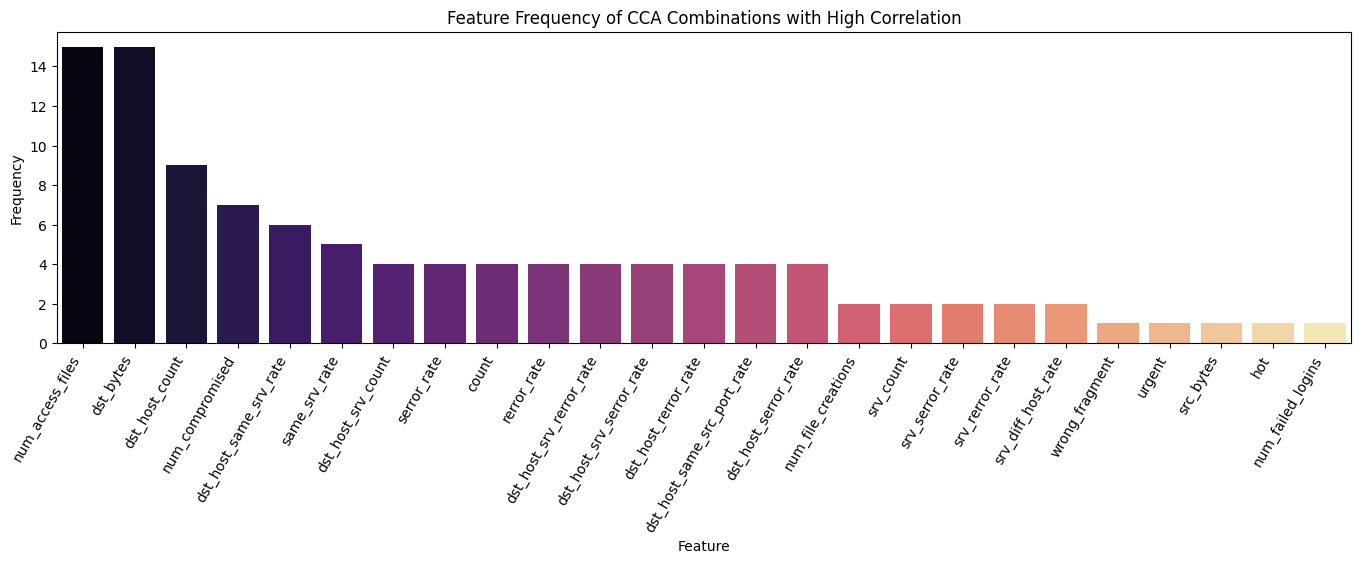

In [ ]:
from collections import Counter
threshold = df_cca_sorted['Canonical_Correlation'].quantile(0.9)
df_filtered = df_cca_sorted[df_cca_sorted['Canonical_Correlation'] >= threshold]
all_features = []

for _, row in df_filtered.iterrows():
    all_features.extend(row['Feature_X'])
    all_features.extend(row['Feature_Y'])

feature_counts = Counter(all_features)

df_feature_freq = pd.DataFrame(feature_counts.items(), columns=['Feature', 'Frequency'])
df_feature_freq = df_feature_freq.sort_values(by='Frequency', ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.barplot(data=df_feature_freq, x='Feature', y='Frequency', palette='magma')

plt.title("Feature Frequency of CCA Combinations with High Correlation")
plt.xlabel("Feature")
plt.ylabel("Frequency")
plt.xticks(rotation=60, ha='right')
plt.tight_layout(pad=2.0)

plt.show()